In [ ]:
# Step 1: Download YOLOv3 weights and configuration files
!wget https://pjreddie.com/media/files/yolov3.weights -O yolov3.weights
!wget https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.cfg -O yolov3.cfg

--2024-10-29 06:20:20--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  29.9MB/s    in 9.8s    

2024-10-29 06:22:47 (24.2 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2024-10-29 06:22:47--  https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.cfg
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg [following]
--2024-10-29 06:22:47--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.c

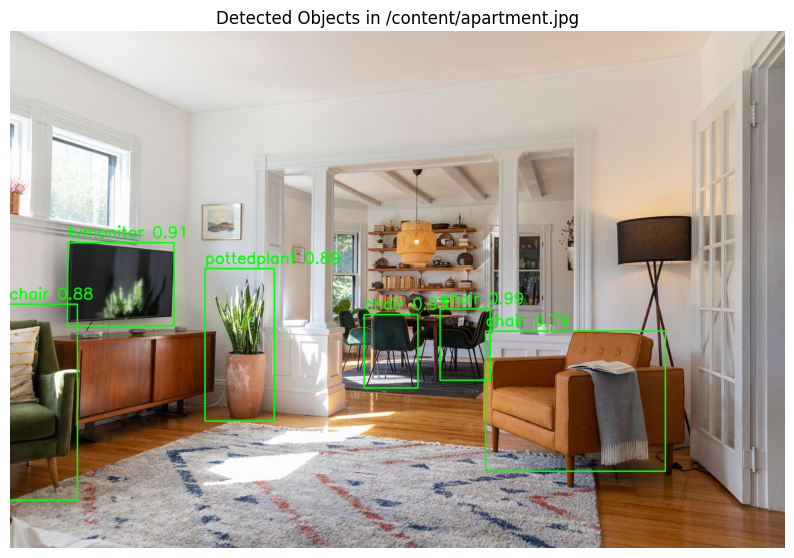

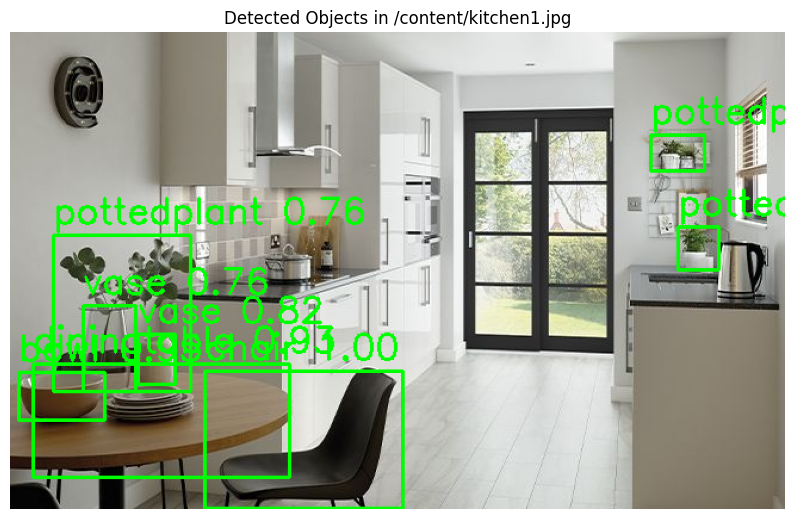

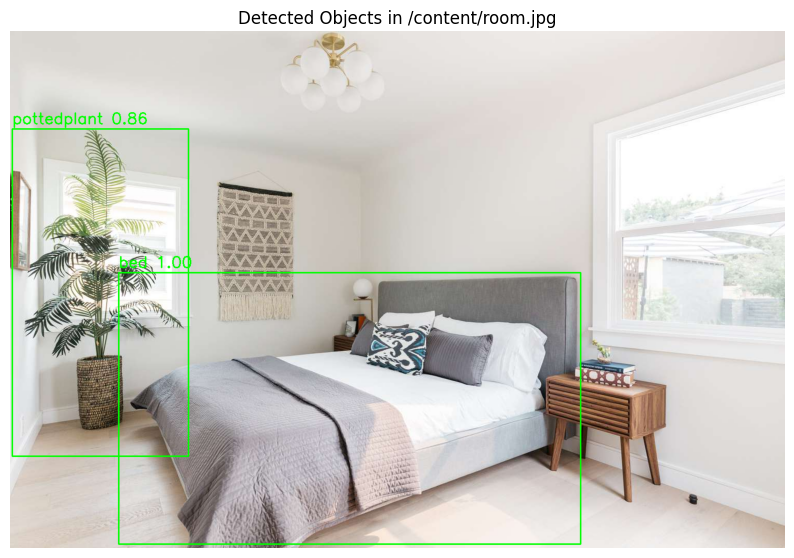

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load YOLO model and configuration
net = cv2.dnn.readNet("/content/yolov3.weights", "/content/yolov3.cfg")
layer_names = net.getLayerNames()
unconnected_out_layers = net.getUnconnectedOutLayers()

# Adjust for OpenCV version differences
if isinstance(unconnected_out_layers, int):
    output_layers = [layer_names[unconnected_out_layers - 1]]
else:
    output_layers = [layer_names[i - 1] for i in unconnected_out_layers.flatten()]

# Load COCO class names (labels)
with open('/content/coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# List of image filenames
image_filenames = [
    "/content/apartment.jpg",  # Replace with your actual file path
    "/content/kitchen1.jpg",     # Add your second image path
    "/content/room.jpg"      # Add your third image path
]

def draw_bounding_boxes(image, boxes, class_ids, confidences, indices):
    if len(indices) > 0:  # Check if NMS returned any valid boxes
        for i in indices.flatten():  # Use flatten() to handle 1D arrays
            box = boxes[i]
            x, y, w, h = box
            label = str(classes[class_ids[i]])
            confidence = confidences[i]
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(image, f'{label} {confidence:.2f}', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
    return image

# Iterate through the list of image filenames
for image_filename in image_filenames:
    # Step 3: Load the image
    image = cv2.imread(image_filename)
    height, width, _ = image.shape

    # Step 4: Prepare the image for YOLO
    blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # Step 5: Extract bounding boxes, class IDs, and confidence scores
    boxes = []
    confidences = []
    class_ids = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:  # Confidence threshold
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply Non-Maximum Suppression (NMS)
    indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)  # Confidence and NMS thresholds

    # Draw bounding boxes and labels on the image
    image_with_boxes = draw_bounding_boxes(image, boxes, class_ids, confidences, indices)

    # Display the result using matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Detected Objects in {image_filename}')
    plt.show()
